In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.options.display.max_columns = None

In [41]:
df = pd.read_excel('data2.xlsx')

feats = ['S2K_item_1', 'S2K_item_2', 'S2K_item_3', 'S2K_item_4', 'S2K_item_5', 'S2K_item_6', 'S2K_item_7', 'S2K_item_8', 
            'S2K_item_9', 'S2K_item_10', 'S2K_item_11', 'S2K_item_12', 'S2K_item_13', 'S2K_item_14', 'S2K_item_15', 'S2K_item_16', 
            'S2K_item_17', 'S2K_item_18', 'S2K_item_19', 'S2K_item_20', 'S2K_item_21', 'S2K_item_22', 'S2K_item_23', 'S2K_item_24']

labels = ['Cumulative_prednisolone_intake_daily_category',
        'Number_mod_severe_drugs','Drug_use_score1',
        'Drug_use_score2', 'Delta_treatment_score']




In [42]:
scaler = MinMaxScaler()

features = df.loc[:, feats]
features = features.apply(lambda x: x / 100)
targets = df.loc[:, labels]
targets_cat = targets.iloc[:,:2]
targets_cont = pd.DataFrame(scaler.fit_transform(targets.iloc[:,2:]))
targets = pd.concat([targets_cat,targets_cont],axis=1)
targets.columns = labels

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, shuffle=True, random_state=42)

In [43]:
y_train

,Cumulative_prednisolone_intake_daily_category,Number_mod_severe_drugs,Drug_use_score1,Drug_use_score2,Delta_treatment_score
1961,1,1,0.0625,0.03125,0.5
1971,0,0,0.0000,0.00000,0.4
631,0,1,0.0625,0.06250,0.4
1563,0,0,0.0000,0.00000,0.4
3455,3,2,0.2500,0.25000,0.6
...,...,...,...,...,...
1095,0,1,0.0625,0.03125,0.4
1130,1,1,0.0625,0.03125,0.4
1294,0,1,0.0625,0.03125,0.4
860,0,2,0.2500,0.25000,0.4


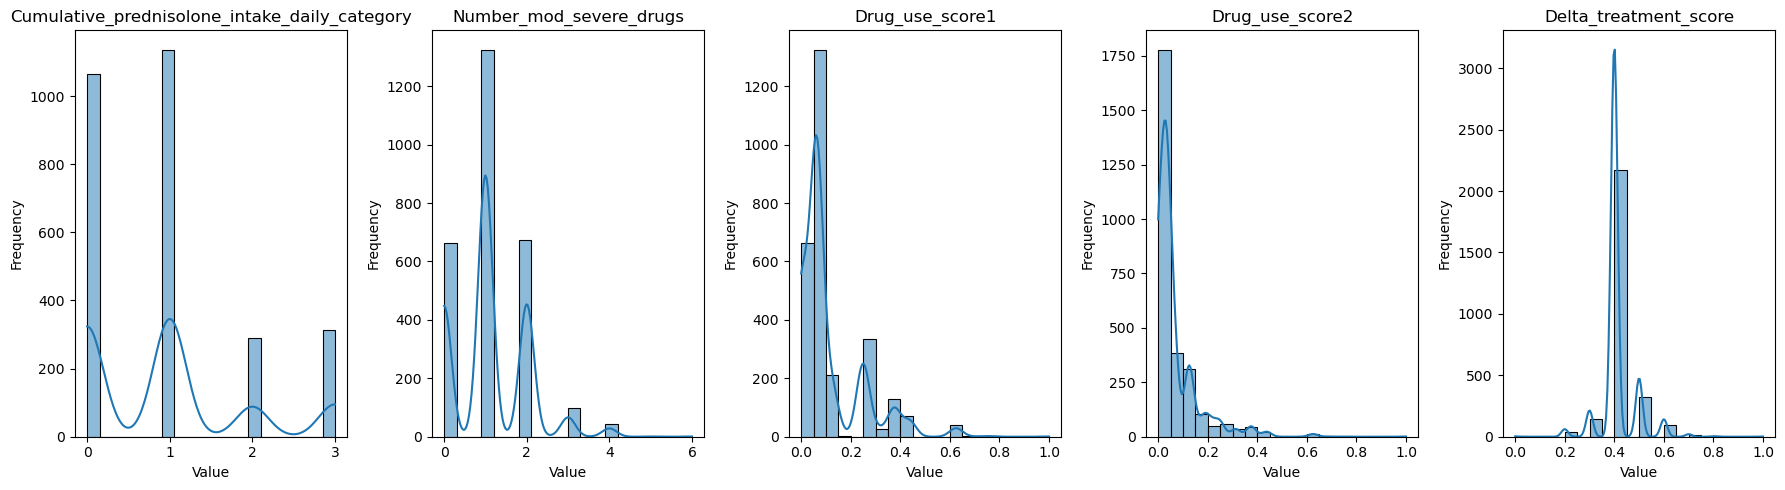

In [44]:
plt.figure(figsize=(18, 5))


# Plot histograms for each target
for i, col in enumerate(y_train.columns):
    plt.subplot(1, len(y_train.columns), i+1)
    sns.histplot(y_train.iloc[:,i], bins=20, kde=True)  # kde=True adds a density curve
    plt.title(col)
    plt.xlabel("Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Cumulative_prednisolone_intake_daily_category Accuracy: 0.49358059914407987
Number_mod_severe_drugs Accuracy: 0.4664764621968616
Drug_use_score1 Loss: 0.016803952337347883
Drug_use_score2 Loss: 0.007267867524986352
Delta_treatment_score Loss: 0.004978218998972198


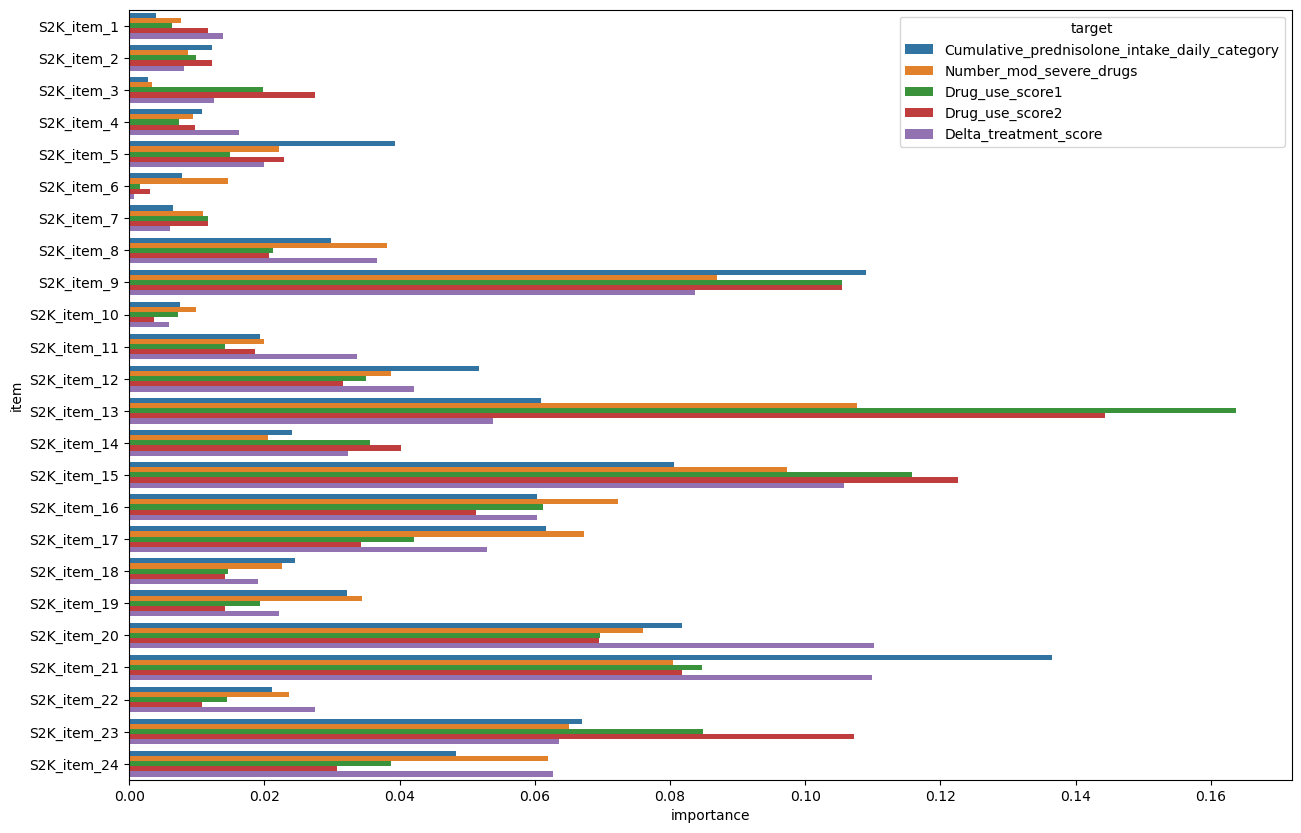

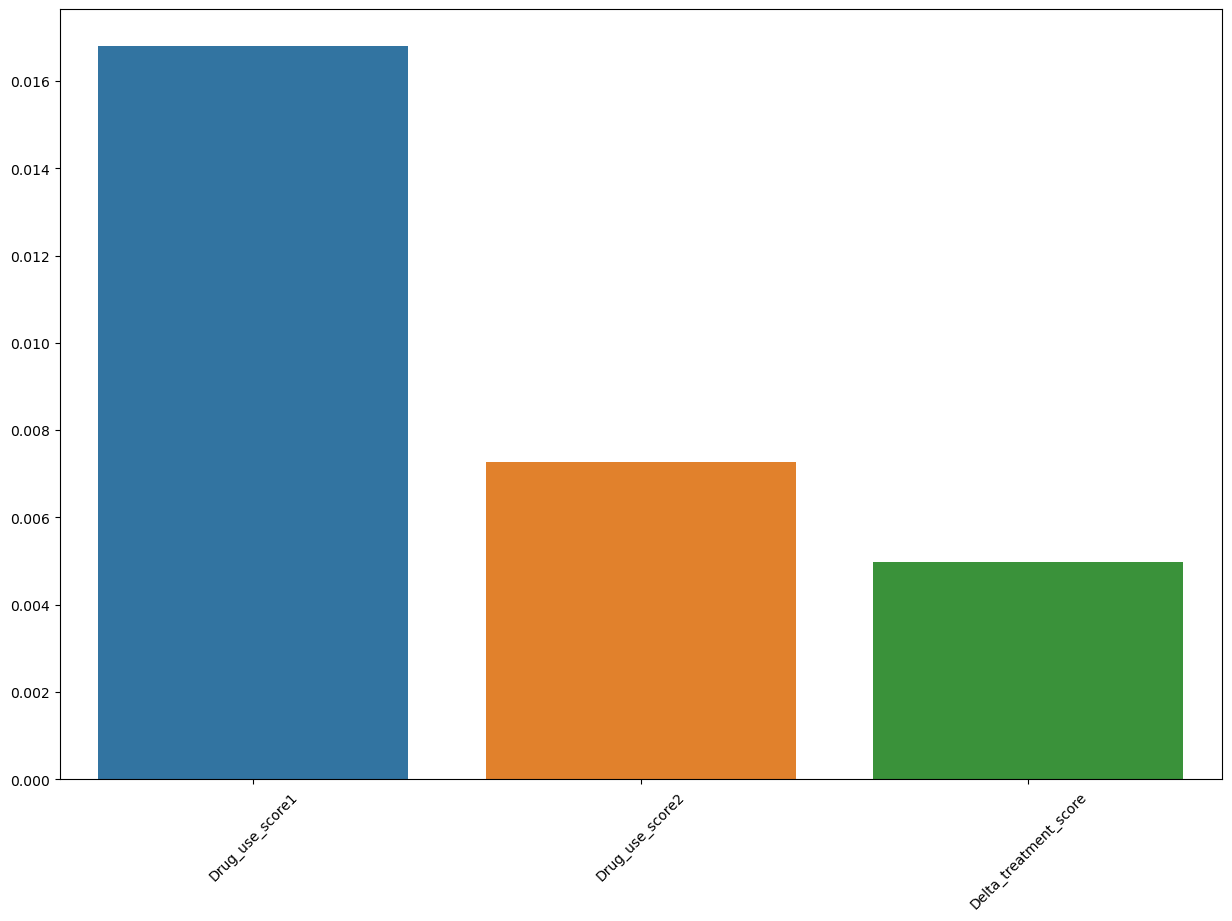

In [45]:
predn_rf = RandomForestClassifier(random_state=42)
sev_drugs_rf = RandomForestClassifier(random_state=42)
du_sc1_rf = RandomForestRegressor(random_state=42)
du_sc2_rf = RandomForestRegressor(random_state=42)
delta_treat_rf = RandomForestRegressor(random_state=42)


regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
reg_names = labels

def regressions():
    losses = {}
    importances = {}
    for i, name in zip(range(len(regressors)), reg_names):
        regressors[i].fit(X_train, y_train[name])
        preds = regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[name], preds)
        importances[name] = regressors[i].feature_importances_
        losses[name] = loss

        if i == 0 or i == 1:
            print(f'{name} Accuracy: {accuracy_score(y_test[name],preds)}')
        else:
            print(f'{name} Loss: {loss}')

    return losses, importances

classification = regressions()

classification[0].pop('Cumulative_prednisolone_intake_daily_category')
classification[0].pop('Number_mod_severe_drugs')


importances_df = pd.DataFrame(classification[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']

plt.figure(figsize=(15,10))
sns.barplot(melted,x='importance',y='item', hue='target')
plt.show()
plt.close()

plt.figure(figsize=(15,10))
sns.barplot(pd.DataFrame.from_dict(classification[0], orient='index').T)
plt.xticks(rotation=45)
plt.show()



Cumulative_prednisolone_intake_daily_category Accuracy: 0.5078459343794579
Number_mod_severe_drugs Accuracy: 0.47360912981455067
Drug_use_score1 Loss: 0.015777994850286713
Drug_use_score2 Loss: 0.0065395426272338575
Delta_treatment_score Loss: 0.004606798208769009


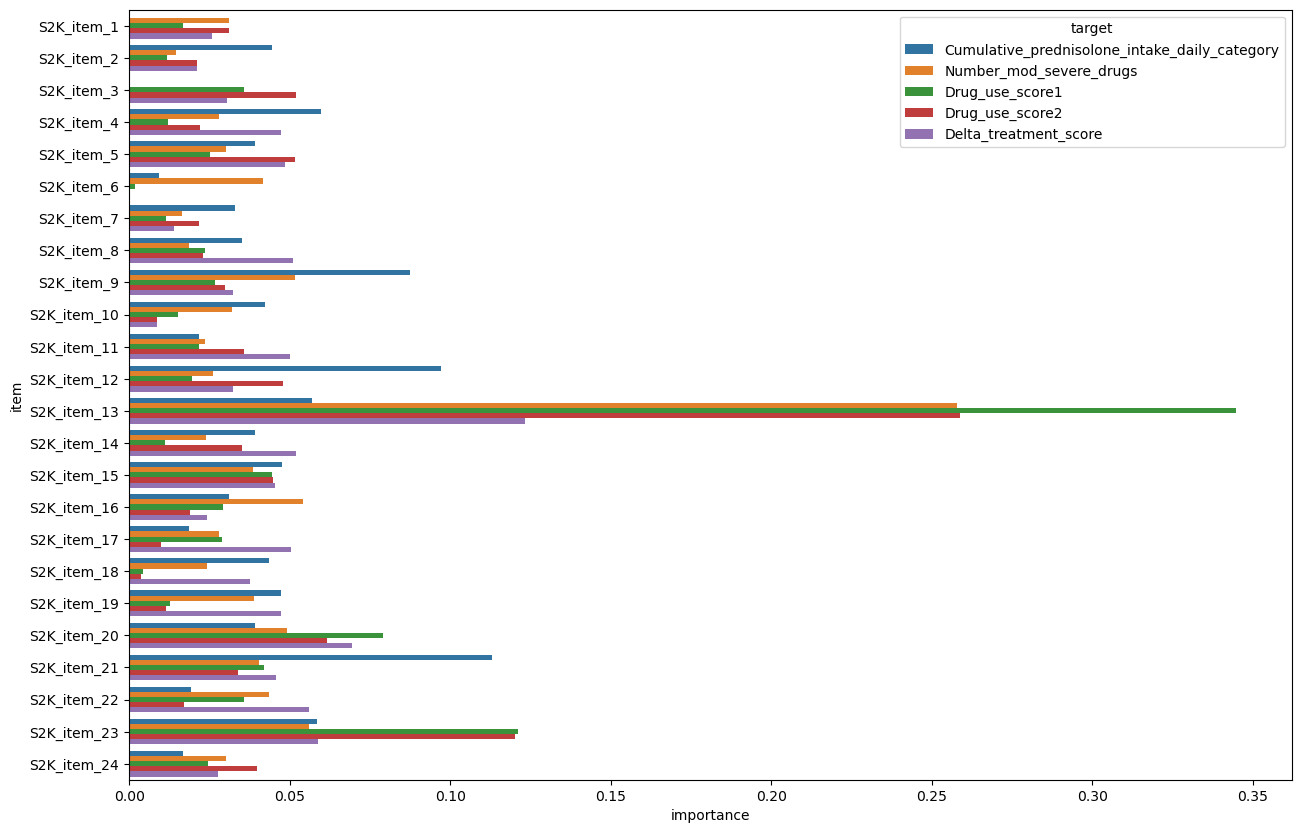

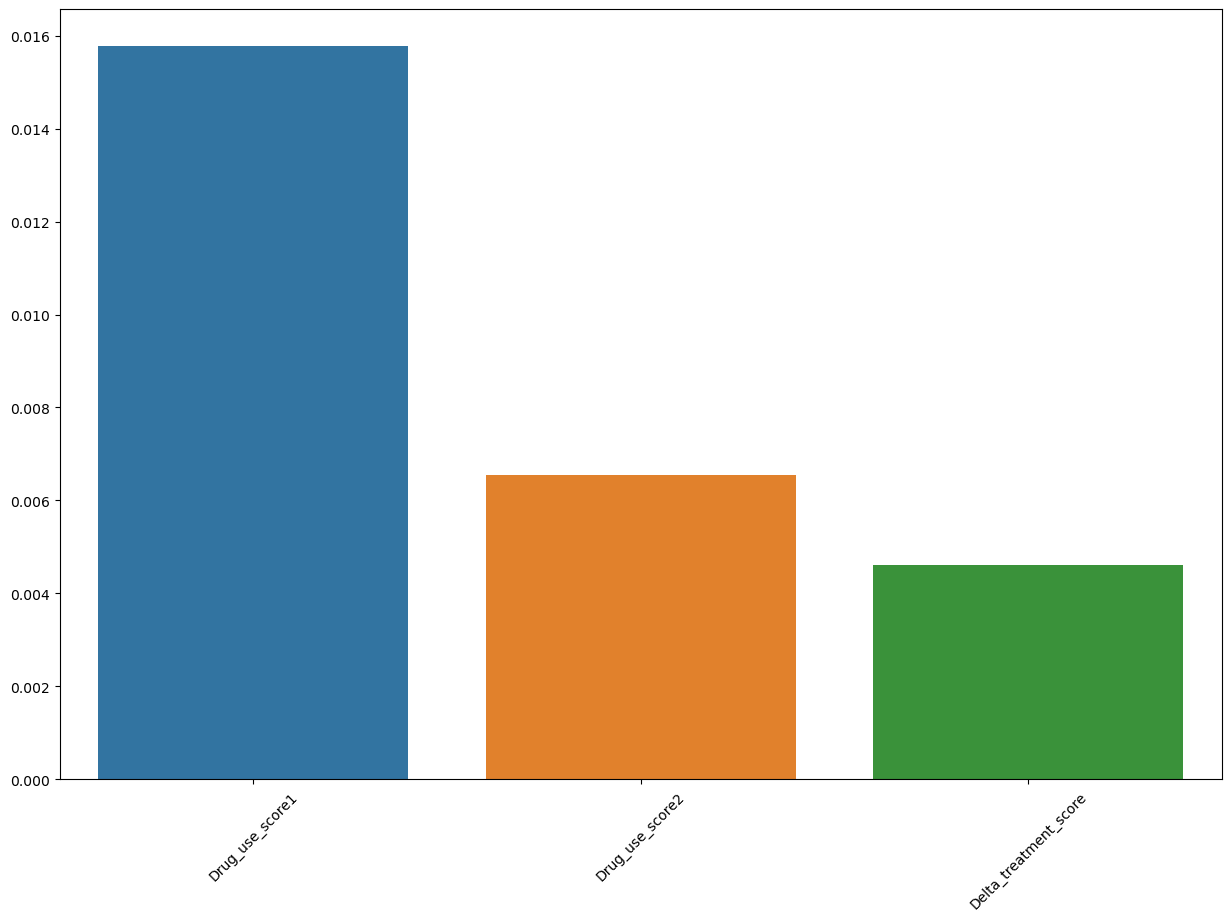

In [46]:
import xgboost

predn_rf = xgboost.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
sev_drugs_rf = xgboost.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
du_sc1_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
du_sc2_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
delta_treat_rf = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)


xgb_regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
xgb_reg_names = labels

def xgb():
    losses = {}
    imps = {}
    for i, name in zip(range(len(xgb_regressors)), xgb_reg_names):
        xgb_regressors[i].fit(X_train, y_train[name])
        preds = xgb_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[name], preds)
        imps[name] = xgb_regressors[i].feature_importances_
        losses[name] = loss

        if i == 0 or i == 1:
            print(f'{name} Accuracy: {accuracy_score(y_test[name],preds)}')
        else:
            print(f'{name} Loss: {loss}')

    return losses, imps

classification = xgb()

classification[0].pop('Cumulative_prednisolone_intake_daily_category')
classification[0].pop('Number_mod_severe_drugs')

importances_df = pd.DataFrame(classification[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','importance']

plt.figure(figsize=(15,10))
sns.barplot(melted,x='importance',y='item', hue='target')
plt.show()

plt.figure(figsize=(15,10))
sns.barplot(pd.DataFrame.from_dict(classification[0], orient='index').T)
plt.xticks(rotation=45)
plt.show()


In [47]:
y_train.shape

(2802, 5)

c:\Users\gsevr\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Cumulative_prednisolone_intake_daily_category Accuracy: 0.4536376604850214
Number_mod_severe_drugs Accuracy: 0.46504992867332384
Drug_use_score1 Loss: 0.01563728390600382
Drug_use_score2 Loss: 0.006486590743121926
Delta_treatment_score Loss: 0.004655184299691296


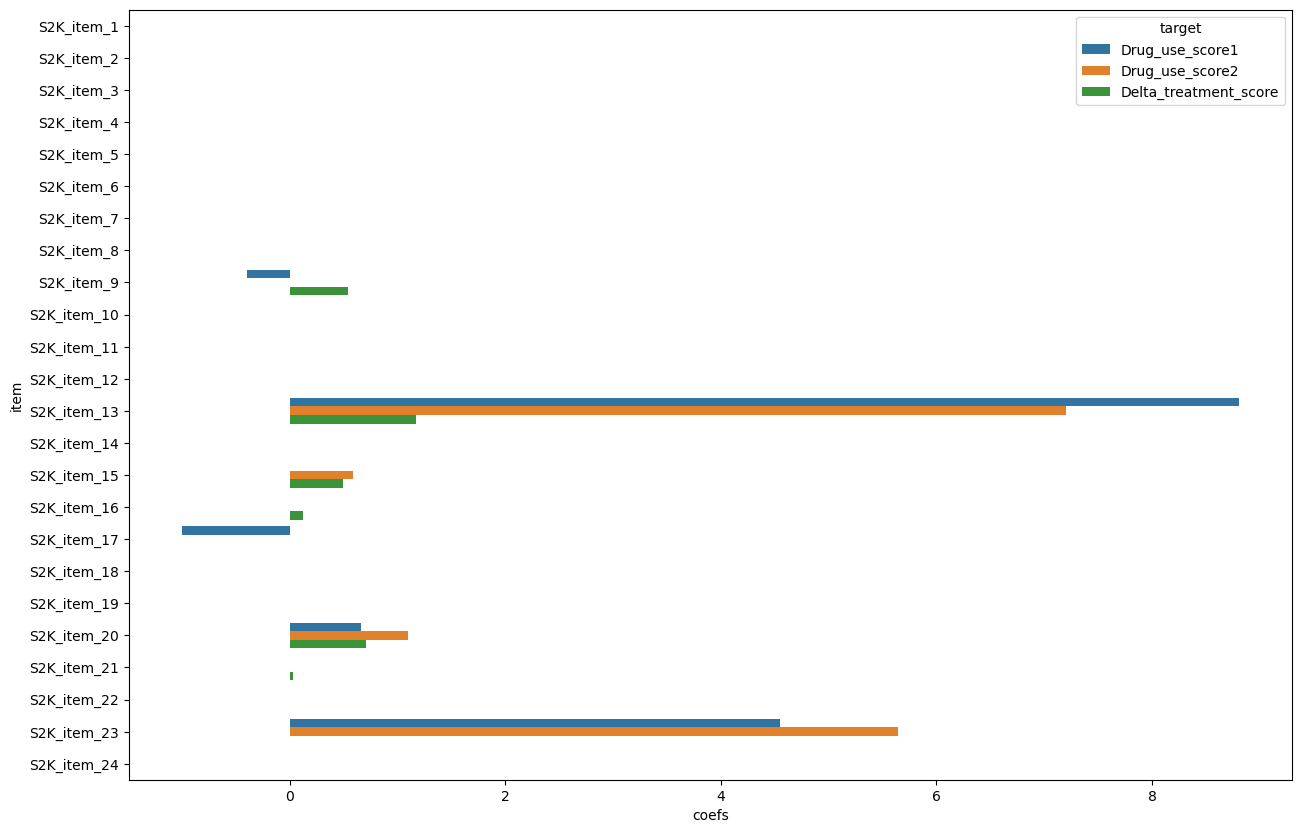

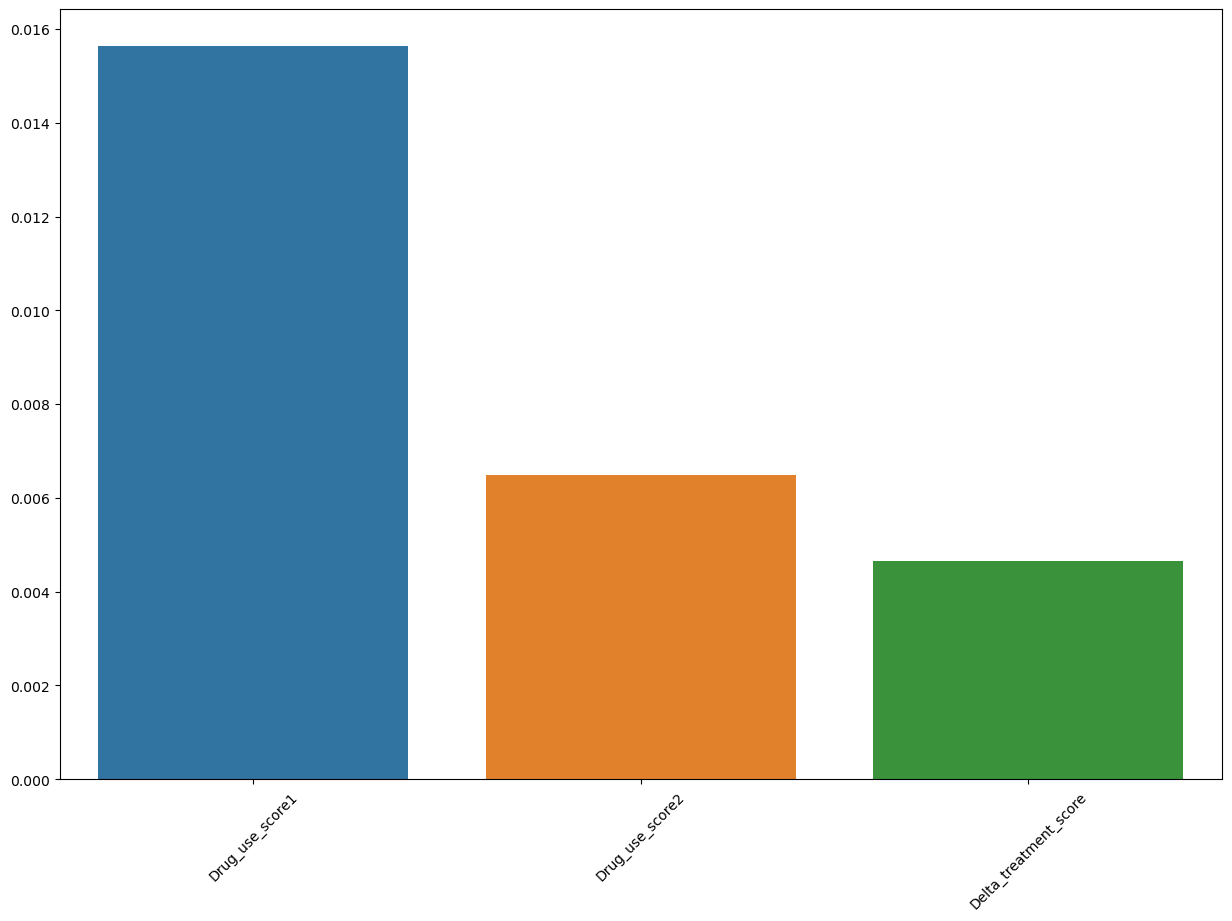

In [48]:
from sklearn.linear_model import Lasso, LogisticRegression

predn_rf = LogisticRegression(penalty='l1', solver='saga', random_state=42)
sev_drugs_rf = LogisticRegression(penalty='l1', solver='saga', random_state=42)
du_sc1_rf = Lasso(alpha=0.00001, random_state=42)
du_sc2_rf = Lasso(alpha=0.00001, random_state=42)
delta_treat_rf = Lasso(alpha=0.00001, random_state=42)


lasso_regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
lasso_reg_names = labels

def lasso():
    losses = {}
    coefs = {}
    for i, name in zip(range(len(lasso_regressors)), lasso_reg_names):
        lasso_regressors[i].fit(X_train, y_train[name])
        preds = lasso_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[name], preds)
        coefs[name] = lasso_regressors[i].coef_
        losses[name] = loss

        if i == 0 or i == 1:
            print(f'{name} Accuracy: {accuracy_score(y_test[name],preds)}')
        else:
            print(f'{name} Loss: {loss}')

    return losses, coefs

classification = lasso()

classification[0].pop('Cumulative_prednisolone_intake_daily_category')
classification[0].pop('Number_mod_severe_drugs')
classification[1].pop('Cumulative_prednisolone_intake_daily_category')
classification[1].pop('Number_mod_severe_drugs')


importances_df = pd.DataFrame(classification[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','coefs']
plt.figure(figsize=(15,10))
sns.barplot(melted,x='coefs',y='item', hue='target')
plt.show()

plt.figure(figsize=(15,10))
sns.barplot(pd.DataFrame.from_dict(classification[0], orient='index').T)
plt.xticks(rotation=45)
plt.show()

Cumulative_prednisolone_intake_daily_category Accuracy: 0.3908701854493581
Number_mod_severe_drugs Accuracy: 0.46504992867332384
Drug_use_score1 Loss: 0.015827074452107178
Drug_use_score2 Loss: 0.00652487978997668
Delta_treatment_score Loss: 0.004616300213108612


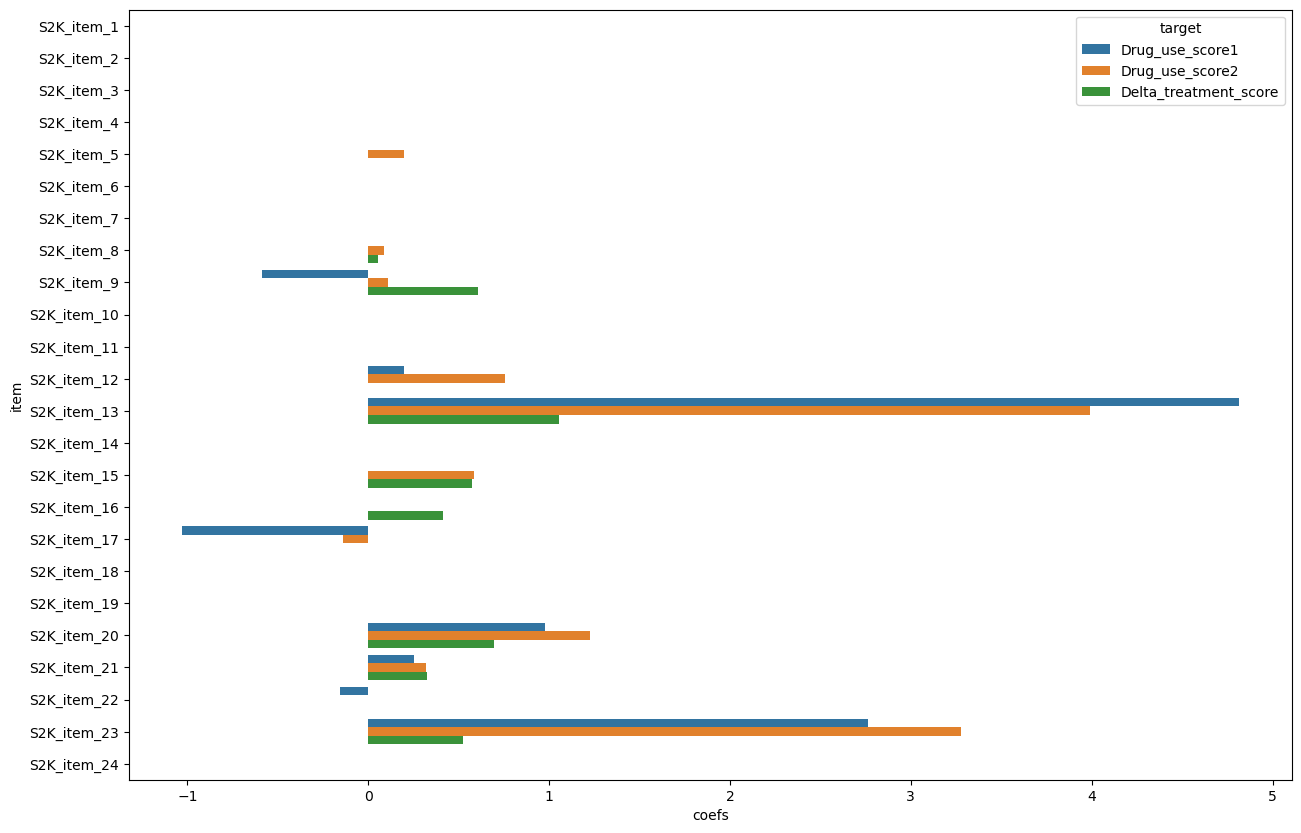

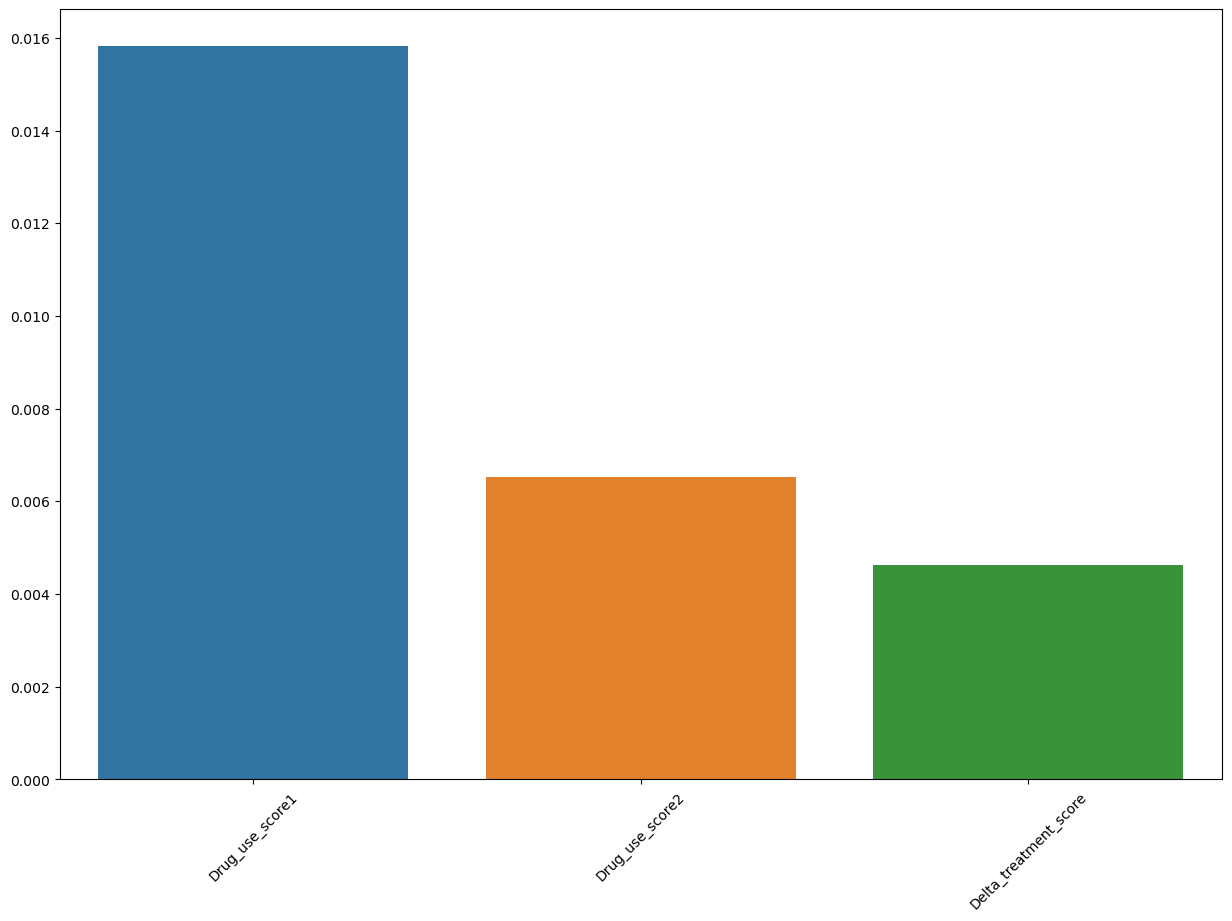

In [49]:
from sklearn.linear_model import ElasticNet

predn_rf = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, random_state=42)
sev_drugs_rf = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, random_state=42)
du_sc1_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)
du_sc2_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)
delta_treat_rf = ElasticNet(alpha=0.00001, l1_ratio=0.5, random_state=42)


elastic_regressors = [predn_rf, sev_drugs_rf, du_sc1_rf, du_sc2_rf, delta_treat_rf]
elastic_reg_names = labels


def elastic():
    losses = {}
    imps = {}
    for i, name in zip(range(len(elastic_regressors)), elastic_reg_names):
        elastic_regressors[i].fit(X_train, y_train[name])
        preds = elastic_regressors[i].predict(X_test)
        loss = mean_squared_error(y_test[name], preds)
        imps[name] = elastic_regressors[i].coef_
        losses[name] = loss

        if i == 0 or i == 1:
            print(f'{name} Accuracy: {accuracy_score(y_test[name],preds)}')
        else:
            print(f'{name} Loss: {loss}')

    return losses, imps

classification = elastic()
classification[0].pop('Cumulative_prednisolone_intake_daily_category')
classification[0].pop('Number_mod_severe_drugs')
classification[1].pop('Cumulative_prednisolone_intake_daily_category')
classification[1].pop('Number_mod_severe_drugs')

importances_df = pd.DataFrame(classification[1],index=feats)

melted = importances_df.reset_index().melt(id_vars='index', var_name='Variable', value_name='Value')
melted.columns = ['item','target','coefs']

plt.figure(figsize=(15,10))
sns.barplot(melted,x='coefs',y='item', hue='target')
plt.show()

plt.figure(figsize=(15,10))
sns.barplot(pd.DataFrame.from_dict(classification[0], orient='index').T)
plt.xticks(rotation=45)
plt.show()